# Problem: Adversarial Attacks

## **<span style="color:orange">Importing Libraries, Declaring Constants, Setting Seed & DEVICE </span>**

CIFAR Model Library

In [27]:
import sys
sys.path.append("pytorch-cifar-models")

import pytorch_cifar_models as pcm

Library

In [28]:
import os
from PIL import Image
import torch.nn as nn
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm import tqdm
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import random

Set DEVICE

In [29]:
DEVICE = "cpu"
# if torch.backends.mps.is_available():
#     DEVICE = "mps"
# elif torch.cuda.is_available():
#     DEVICE = "cuda"

print(f"Using device: {DEVICE}")

Using device: cpu


Constants

In [30]:
BATCH_SIZE = 4

In [31]:
CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [32]:
CIFAR10_DIR = "./cifar10_correct_samples"
RESENET20_WEIGHTS = "./cifar10_resnet20-4118986f.pt"

## **<span style="color:orange">Load Model & Data</span>**

Load model

In [33]:
model = pcm.cifar10_resnet20(pretrained=False)

In [34]:
state_dict = torch.load(RESENET20_WEIGHTS, map_location=DEVICE)
model.load_state_dict(state_dict)
model.eval()
model.to(DEVICE)

CifarResNet(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias

Load image

In [35]:
class CIFARCustomDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.files = [
            f for f in os.listdir(root_dir)
            if f.endswith(".png")
        ]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        filename = self.files[idx]
        path = os.path.join(self.root_dir, filename)

        # load image
        image = Image.open(path).convert("RGB")

        # parse label from filename: "..._true3.png"
        label_str = filename.split("_true")[1].split(".png")[0]
        label = int(label_str)

        if self.transform:
            image = self.transform(image)

        return image, label

In [36]:
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
std  = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean.flatten().tolist(),
                        std=std.flatten().tolist())
])

dataset = CIFARCustomDataset(
    root_dir=CIFAR10_DIR,
    transform=transform
)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

In [37]:
print(f"Number of images: {len(dataset)}")
print(f"Number of batches: {len(dataloader)}")

Number of images: 25
Number of batches: 7


Check Model and Dataset Load

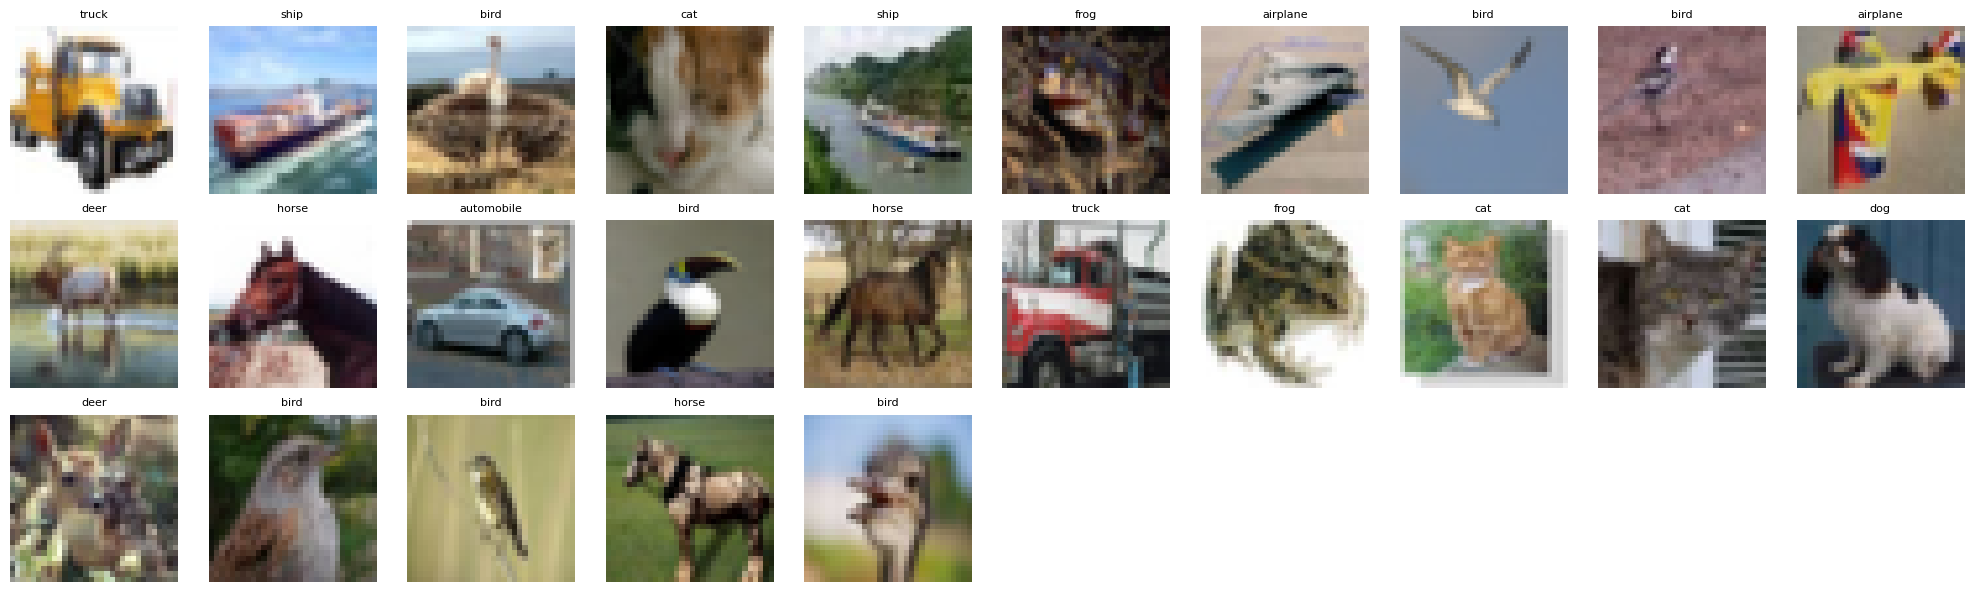

In [38]:
num_images = len(dataset)
cols = 10
rows = 3

fig, axes = plt.subplots(rows, cols, figsize=(2 * cols, 2 * rows))
axes = np.array(axes).reshape(-1)

for i in range(num_images):
    img, true_lbl = dataset[i]
    img = img * std + mean
    img = torch.clamp(img, 0, 1)

    axes[i].imshow(img.permute(1, 2, 0).numpy())
    axes[i].set_title(f"{CIFAR10_CLASSES[true_lbl]}", fontsize=8)
    axes[i].axis("off")

for j in range(num_images, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [40]:
def evaluate(model, data_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(data_loader):
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    return accuracy

In [41]:
accuracy_clean_data = evaluate(model, dataloader)
print(f"Accuracy of the model on the {len(dataset)} clean images: {accuracy_clean_data:.4f}")

100%|██████████| 7/7 [00:00<00:00, 50.05it/s]

Accuracy of the model on the 25 clean images: 1.0000


## **<span style="color:orange">Attacks</span>**

### زیربخش دوم

In [42]:
eps = 0.03
criterion = nn.CrossEntropyLoss()

successful_adv = []
correct_after_attack = 0

model.eval()

for images, labels in dataloader:
    images = images.to(DEVICE)
    labels = labels.to(DEVICE)

    images.requires_grad_()

    outputs = model(images)
    loss = criterion(outputs, labels)

    model.zero_grad()
    loss.backward()

    noise = eps * images.grad.sign()
    adv_images = images + noise

    with torch.no_grad():
        adv_outputs = model(adv_images)
        adv_predicts = adv_outputs.argmax(dim=1)

    correct_after_attack += (adv_predicts == labels).sum().item()

    for i in range(len(labels)):
        if adv_predicts[i] != labels[i]:
            successful_adv.append((images[i].detach(), adv_images[i].detach(), noise[i].detach(), labels[i].detach(), adv_predicts[i].detach()))

fgsm_acc = 100 * correct_after_attack / 25

print("After FGSM Attack:")
print("Number of incorrect model outputs:", len(successful_adv))
print(f"Model Accuracy: {fgsm_acc:.2f}%")

After FGSM Attack:
Number of incorrect model outputs: 18
Model Accuracy: 28.00%


In [43]:
def unnormalize(img):
    img = img * std + mean
    img = torch.clamp(img, 0, 1)
    return img.detach().cpu().permute(1, 2, 0)

def show_desired_items(adv_examples, title):
    num_show = 4
    random_indices = random.sample(range(len(adv_examples)), num_show)

    plt.figure(figsize=(8, 1.8 * num_show))

    for i, idx in enumerate(random_indices):
        org, adv, noise, label, pred = adv_examples[idx]

        true_label = CIFAR10_CLASSES[label.item()]
        wrong_label = CIFAR10_CLASSES[pred.item()]

        plt.subplot(num_show, 3, 3*i + 1)
        plt.imshow(unnormalize(org), interpolation="nearest")
        plt.title(f"Original\nTrue: {true_label}", fontsize=8)
        plt.axis("off")

        plt.subplot(num_show, 3, 3*i + 2)
        plt.imshow(unnormalize(adv), interpolation="nearest")
        plt.title(f"Adversarial\nPred: {wrong_label}", fontsize=8)
        plt.axis("off")

        plt.subplot(num_show, 3, 3*i + 3)
        n = noise.cpu().permute(1, 2, 0)
        n = (n - n.min()) / (n.max() - n.min() + 1e-8)
        plt.imshow(n, interpolation="nearest")
        plt.title("Noise", fontsize=8)
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

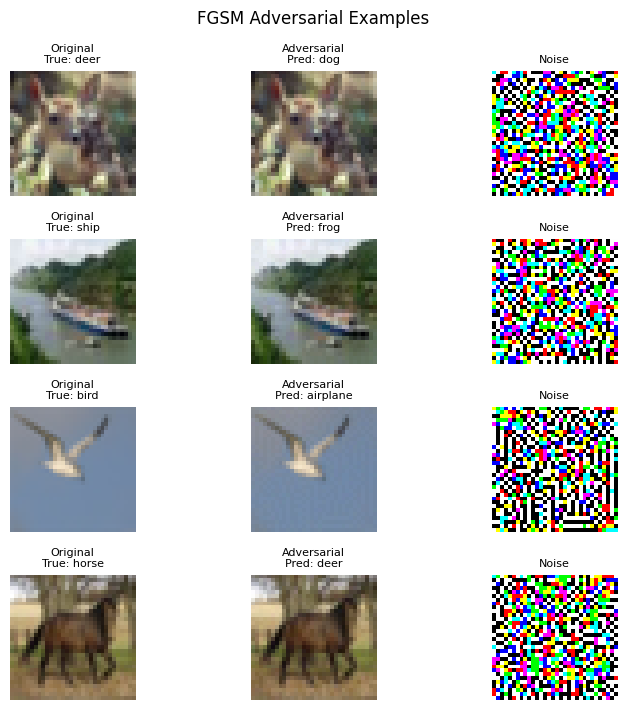

In [44]:
show_desired_items(successful_adv, title="FGSM Adversarial Examples")

### زیربخش سوم

In [45]:
eps = 0.03
alpha = 0.005
steps = 20
criterion = nn.CrossEntropyLoss()

successful_adv = []
correct_after_attack = 0

model.eval()

lower = (0 - mean) / std
upper = (1 - mean) / std

for images, labels in dataloader:
    images = images.to(DEVICE)
    labels = labels.to(DEVICE)

    org_images = images.clone().detach()
    adv_images = images.clone().detach()

    for _ in range(steps):
        adv_images.requires_grad_()

        outputs = model(adv_images)
        loss = criterion(outputs, labels)

        model.zero_grad()
        loss.backward()

        adv_images = adv_images + alpha * adv_images.grad.sign()

        delta = torch.clamp(adv_images - org_images, min=-eps, max=eps)
        adv_images = org_images + delta

        adv_images = torch.max(torch.min(adv_images, upper), lower).detach()

    noise = adv_images - org_images
    
    with torch.no_grad():
        adv_outputs = model(adv_images)
        adv_predicts = adv_outputs.argmax(dim=1)

    correct_after_attack += (adv_predicts == labels).sum().item()


    for i in range(len(labels)):
        if adv_predicts[i] != labels[i]:
            successful_adv.append((org_images[i].detach(), adv_images[i].detach(), noise[i].detach(), labels[i].detach(), adv_predicts[i].detach()))

pgd_acc = 100 * correct_after_attack / 25
print("After PGD Attack:")
print("Number of incorrect model outputs:", len(successful_adv))
print(f"Model Accuracy: {pgd_acc:.2f}%")

After PGD Attack:
Number of incorrect model outputs: 24
Model Accuracy: 4.00%


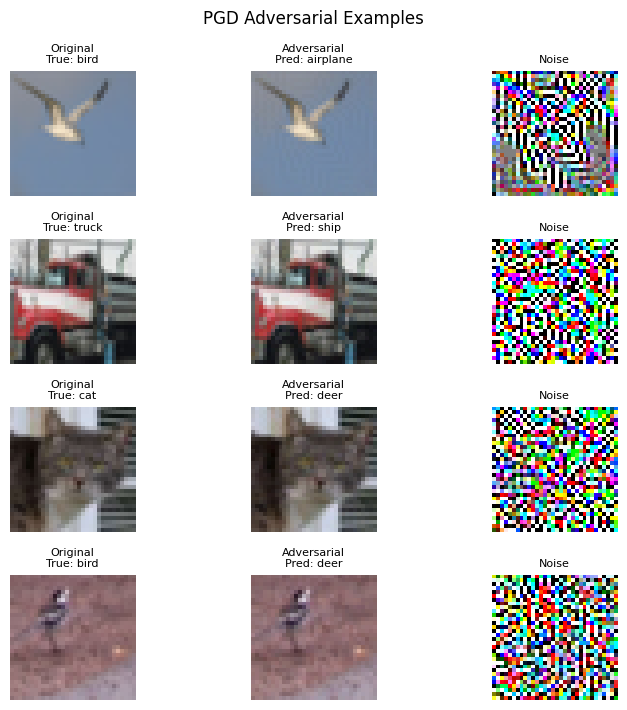

In [46]:
show_desired_items(successful_adv, title="PGD Adversarial Examples")